你的配送路径是： [array([0, 0]), array([2, 3]), array([4, 5]), array([5, 8]), array([1, 9]), array([7, 2])]


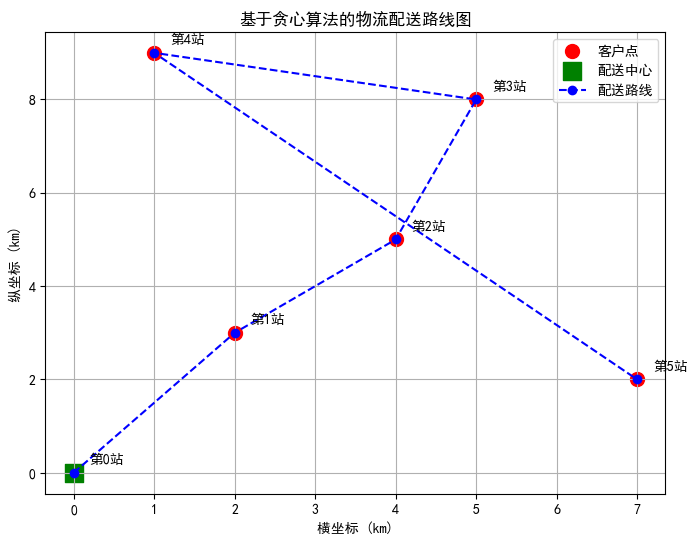

In [2]:
import numpy as np

# 1. 定义客户坐标 (x, y)
customers = np.array([
    [2, 3], [5, 8], [1, 9], [7, 2], [4, 5]
])
current_pos = np.array([0, 0]) # 出发点
visited = [False] * len(customers) # 类似 BFS 的 visited 数组
path = [current_pos]

# 2. 贪心循环：只要还有没去过的点，就找最近的
for _ in range(len(customers)):
    min_dist = float('inf')
    next_node = -1
    
    for i in range(len(customers)):
        if not visited[i]:
            # 计算欧几里得距离 (C++里你可能要写 sqrt(pow...))
            dist = np.linalg.norm(current_pos - customers[i])
            if dist < min_dist:
                min_dist = dist
                next_node = i
                
    # 移动到最近的点
    visited[next_node] = True
    current_pos = customers[next_node]
    path.append(current_pos)

print("你的配送路径是：", path)
import matplotlib.pyplot as plt

# 1. 提取路径的 x 和 y 坐标
path_x = [p[0] for p in path]
path_y = [p[1] for p in path]

# 2. 创建画布
plt.figure(figsize=(8, 6))

# 3. 画出客户点（散点图）
plt.scatter(customers[:, 0], customers[:, 1], color='red', label='客户点', s=100)
# 画出起点（用不同的颜色和形状）
plt.scatter(0, 0, color='green', marker='s', s=150, label='配送中心')

# 4. 画出配送路线（折线图）
plt.plot(path_x, path_y, color='blue', linestyle='--', marker='o', label='配送路线')

# 5. 给每个点标上序号（这是程序员的细节！）
for i, pos in enumerate(path):
    plt.text(pos[0]+0.2, pos[1]+0.2, f'第{i}站', fontsize=10)

# 6. 修饰：设置中文、标题、图例
plt.rcParams['font.sans-serif'] = ['SimHei'] # 支持中文
plt.title('基于贪心算法的物流配送路线图')
plt.xlabel('横坐标 (km)')
plt.ylabel('纵坐标 (km)')
plt.legend()
plt.grid(True) # 加个网格线，看起来更专业

# 7. 显示
plt.show()